In [49]:
#Load the dataset in Python
import pandas as pd
from pathlib import Path
file_name = "/content/drive/MyDrive/AI Programming/Assignment 5/swiftship_delivery_delay_dataset.xlsx"
data_path = Path(file_name)
print("Current dataset path:", data_path)
print("File exists:", data_path.exists())

df = pd.read_excel(data_path)
print("Dataset loaded successfully!")

df.head()

Current dataset path: /content/drive/MyDrive/AI Programming/Assignment 5/swiftship_delivery_delay_dataset.xlsx
File exists: True
Dataset loaded successfully!


,Shipment_ID,Order_Date,Customer_Segment,Region,Product_Category,Shipping_Method,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Warehouse_Load_Level,Carrier_Rating,Weather_Risk,Previous_Delivery_Issues,Peak_Season,Promised_Delivery_Days,Delivery_Delayed
0,SHP-10001,2026-02-26,Small Business,Ontario,Home Goods,Economy,485,9.8,344.55,High,3.4,Low,0,No,7,0
1,SHP-10002,2026-04-07,Small Business,British Columbia,Apparel,Express,351,10.5,543.41,Low,4.0,Low,2,No,2,1
2,SHP-10003,2026-02-23,E-commerce Seller,British Columbia,Office Supplies,Economy,713,11.1,448.06,High,2.5,High,0,No,6,1
3,SHP-10004,2026-03-10,Enterprise,Ontario,Office Supplies,Express,531,12.2,659.53,Medium,4.0,Medium,2,Yes,1,1
4,SHP-10005,2026-05-11,E-commerce Seller,Atlantic,Apparel,Express,33,14.8,200.73,Medium,4.2,Medium,0,No,2,0


In [50]:
#Inspect the Dataset
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

df.describe()

Shape: (355, 16)

Column Names:
['Shipment_ID', 'Order_Date', 'Customer_Segment', 'Region', 'Product_Category', 'Shipping_Method', 'Shipping_Distance_km', 'Package_Weight_kg', 'Order_Value_CAD', 'Warehouse_Load_Level', 'Carrier_Rating', 'Weather_Risk', 'Previous_Delivery_Issues', 'Peak_Season', 'Promised_Delivery_Days', 'Delivery_Delayed']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 355 entries, 0 to 354
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Shipment_ID               355 non-null    object 
 1   Order_Date                355 non-null    object 
 2   Customer_Segment          355 non-null    object 
 3   Region                    352 non-null    object 
 4   Product_Category          355 non-null    object 
 5   Shipping_Method           355 non-null    object 
 6   Shipping_Distance_km      355 non-null    int64  
 7   Package_Weight_kg         350 non-null    float64
 8 

,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Carrier_Rating,Previous_Delivery_Issues,Promised_Delivery_Days,Delivery_Delayed
count,355.000000,350.000000,355.000000,351.000000,355.000000,355.000000,355.000000
mean,408.619718,8.498857,367.969577,4.059259,0.991549,3.095775,0.292958
std,218.734235,4.574941,189.926697,0.486936,1.118633,1.899110,0.455762
min,15.000000,0.200000,25.000000,2.500000,0.000000,0.000000,0.000000
25%,236.500000,5.300000,226.655000,3.700000,0.000000,2.000000,0.000000
50%,391.000000,8.200000,373.690000,4.100000,1.000000,3.000000,0.000000
75%,568.000000,11.675000,508.665000,4.400000,2.000000,4.000000,1.000000
max,1062.000000,21.200000,842.360000,5.000000,4.000000,7.000000,1.000000


In [51]:
#Clean the Dataset
df_clean = df.copy()

df_clean.columns = df_clean.columns.str.strip()

df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Shape after removing duplicates: (350, 16)


In [52]:
numerical_columns = [
    'Shipping_Distance_km',
    'Package_Weight_kg',
    'Order_Value_CAD',
    'Carrier_Rating',
    'Previous_Delivery_Issues',
    'Promised_Delivery_Days',
    'Delivery_Delayed'
]

for col in numerical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [53]:
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())


Missing values after cleaning:
Shipment_ID                 0
Order_Date                  0
Customer_Segment            0
Region                      3
Product_Category            0
Shipping_Method             0
Shipping_Distance_km        0
Package_Weight_kg           0
Order_Value_CAD             0
Warehouse_Load_Level        0
Carrier_Rating              0
Weather_Risk                0
Previous_Delivery_Issues    0
Peak_Season                 0
Promised_Delivery_Days      0
Delivery_Delayed            0
dtype: int64


In [54]:
#Features for Clustering
features = [
    'Shipping_Distance_km',
    'Package_Weight_kg',
    'Order_Value_CAD',
    'Carrier_Rating',
    'Previous_Delivery_Issues',
    'Promised_Delivery_Days'
]

X = df_clean[features]

print("Selected features shape:", X.shape)
X.head()

Selected features shape: (350, 6)


,Shipping_Distance_km,Package_Weight_kg,Order_Value_CAD,Carrier_Rating,Previous_Delivery_Issues,Promised_Delivery_Days
0,485,9.8,344.55,3.4,0,7
1,351,10.5,543.41,4.0,2,2
2,713,11.1,448.06,2.5,0,6
3,531,12.2,659.53,4.0,2,1
4,33,14.8,200.73,4.2,0,2


In [55]:
#Scale the Features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Mean after scaling (should be ~0):")
print(X_scaled_df.mean().round(4))
print("\nStd after scaling (should be ~1):")
print(X_scaled_df.std().round(4))

Mean after scaling (should be ~0):
Shipping_Distance_km        0.0
Package_Weight_kg          -0.0
Order_Value_CAD            -0.0
Carrier_Rating             -0.0
Previous_Delivery_Issues    0.0
Promised_Delivery_Days     -0.0
dtype: float64

Std after scaling (should be ~1):
Shipping_Distance_km        1.0014
Package_Weight_kg           1.0014
Order_Value_CAD             1.0014
Carrier_Rating              1.0014
Previous_Delivery_Issues    1.0014
Promised_Delivery_Days      1.0014
dtype: float64


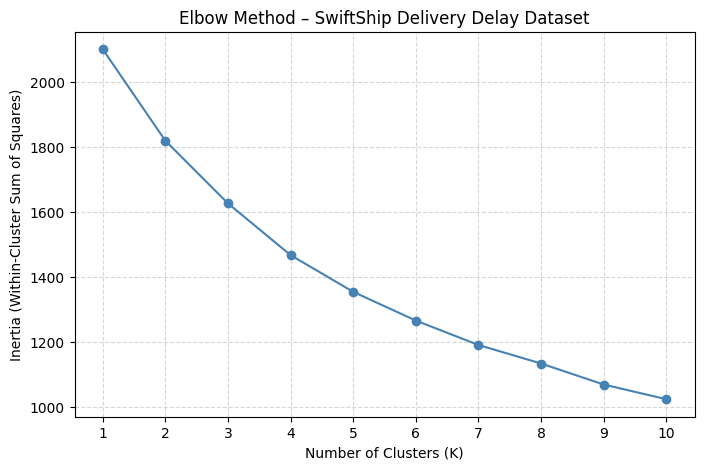

In [56]:
#Elbow Method to Choose K
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method – SwiftShip Delivery Delay Dataset")
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [57]:
elbow_results = pd.DataFrame({"K": list(K_range), "Inertia": inertia})
print(elbow_results)

    K      Inertia
0   1  2100.000000
1   2  1818.805856
2   3  1626.018145
3   4  1467.017181
4   5  1354.093472
5   6  1265.810510
6   7  1190.717627
7   8  1133.786618
8   9  1069.188499
9  10  1024.013375


In [58]:
print('''
Reasons of choosing K = 3:
- The Elbow Method plot shows a noticeable "bend" (elbow) at K = 3,
where the rate of inertia decrease slows down significantly.
- Beyond K = 3, adding more clusters yields diminishing returns.
- K = 3 also makes practical business sense: it allows us to distinguish shipments into Low-Risk, Moderate-Risk, and high-Risk delivery groups without over-complicating the model.
''')


Reasons of choosing K = 3:
- The Elbow Method plot shows a noticeable "bend" (elbow) at K = 3,
where the rate of inertia decrease slows down significantly.
- Beyond K = 3, adding more clusters yields diminishing returns.
- K = 3 also makes practical business sense: it allows us to distinguish shipments into Low-Risk, Moderate-Risk, and high-Risk delivery groups without over-complicating the model.



In [59]:
#Train the Final K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

print("Cluster label counts:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster label counts:
0    166
1     92
2     92
Name: count, dtype: int64


In [60]:
#Add Cluster Labels Back to the Dataset
df_clustered = df_clean.copy()
df_clustered["Cluster"] = cluster_labels

print("Dataset with cluster labels:")
df_clustered[["Shipment_ID", "Shipping_Distance_km", "Order_Value_CAD",
              "Carrier_Rating", "Cluster"]].head(10)

Dataset with cluster labels:


,Shipment_ID,Shipping_Distance_km,Order_Value_CAD,Carrier_Rating,Cluster
0,SHP-10001,485,344.55,3.4,1
1,SHP-10002,351,543.41,4.0,2
2,SHP-10003,713,448.06,2.5,1
3,SHP-10004,531,659.53,4.0,2
4,SHP-10005,33,200.73,4.2,0
5,SHP-10006,480,549.71,4.3,2
6,SHP-10007,359,710.27,3.9,1
7,SHP-10008,922,646.79,3.4,1
8,SHP-10009,15,677.78,3.7,0
9,SHP-10010,439,627.56,4.4,2


In [61]:
#Cluster Summary
cluster_summary = df_clustered.groupby("Cluster")[features].mean().round(2)
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
cluster_summary["Shipment_Count"] = cluster_counts
print(cluster_summary)

         Shipping_Distance_km  Package_Weight_kg  Order_Value_CAD  \
Cluster                                                             
0                      346.45               8.72           372.55   
1                      516.33               8.33           401.68   
2                      410.41               8.23           324.29   

         Carrier_Rating  Previous_Delivery_Issues  Promised_Delivery_Days  \
Cluster                                                                     
0                  4.00                      0.34                    2.04   
1                  3.97                      0.76                    5.47   
2                  4.27                      2.39                    2.54   

         Shipment_Count  
Cluster                  
0                   166  
1                    92  
2                    92  


In [62]:
summary = cluster_summary.copy()
low_risk_cluster   = summary["Carrier_Rating"].idxmax()
high_risk_cluster  = summary["Previous_Delivery_Issues"].idxmax()
moderate_cluster   = [i for i in summary.index
                      if i not in [low_risk_cluster, high_risk_cluster]][0]

segment_names = {
    low_risk_cluster:  "Low-Risk Shipments",
    moderate_cluster:  "Moderate-Risk Shipments",
    high_risk_cluster: "High-Risk Shipments"
}

df_clustered["Segment_Name"] = df_clustered["Cluster"].map(segment_names)

print(df_clustered["Segment_Name"].value_counts())

Segment_Name
Moderate-Risk Shipments    166
High-Risk Shipments         92
Name: count, dtype: int64


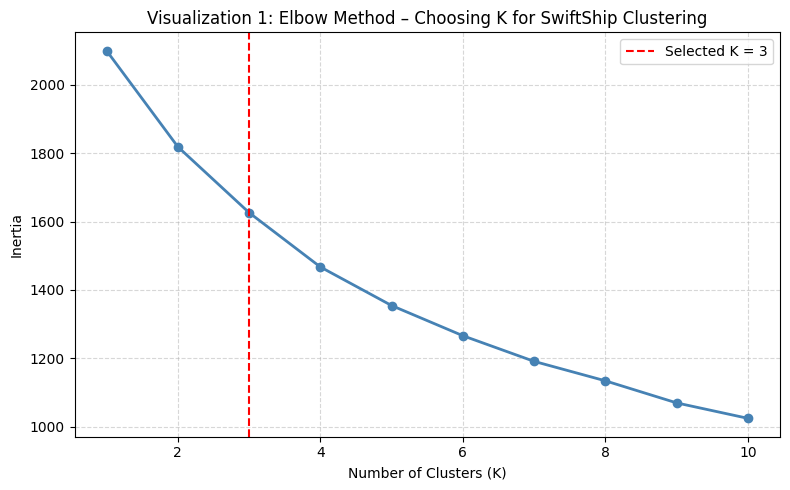

In [63]:
#Visualize the Clusters
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=3, color='red', linestyle='--', label='Selected K = 3')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Visualization 1: Elbow Method – Choosing K for SwiftShip Clustering")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [64]:
print('''
The elbow curve shows a clear bend at K = 3. Inertia drops steeply
from K = 1 to K = 3, then levels off. This indicates that 3 clusters
capture the main structural groupings in the data without overfitting.
''')


The elbow curve shows a clear bend at K = 3. Inertia drops steeply
from K = 1 to K = 3, then levels off. This indicates that 3 clusters
capture the main structural groupings in the data without overfitting. 



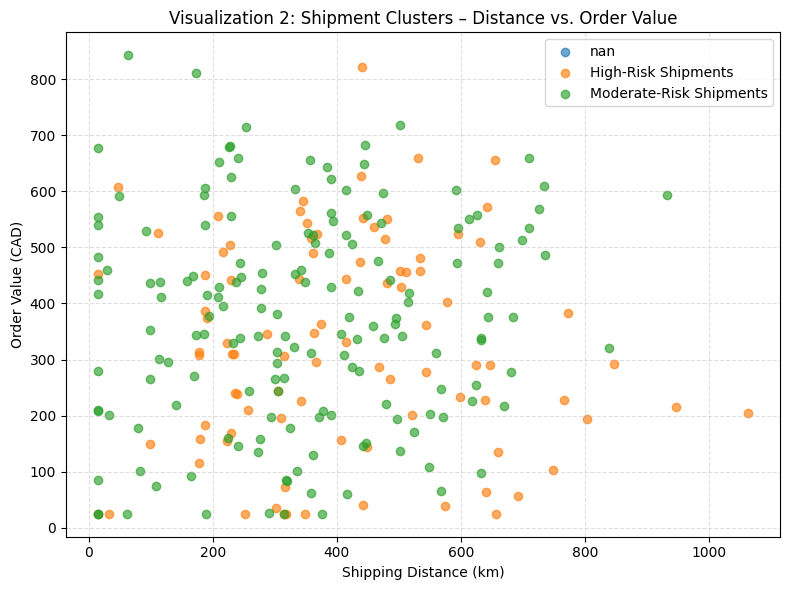

In [65]:
#Visualization: Scatter Plot
plt.figure(figsize=(8, 6))

colors = {"Low-Risk Shipments": "green",
          "Moderate-Risk Shipments": "orange",
          "High-Risk Shipments": "red"}

for segment in df_clustered["Segment_Name"].unique():
    seg_data = df_clustered[df_clustered["Segment_Name"] == segment]
    plt.scatter(
        seg_data["Shipping_Distance_km"],
        seg_data["Order_Value_CAD"],
        label=segment,
        alpha=0.65,
    )

plt.xlabel("Shipping Distance (km)")
plt.ylabel("Order Value (CAD)")
plt.title("Visualization 2: Shipment Clusters – Distance vs. Order Value")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [66]:
print('''
The scatter plot reveals how the three segments are distributed across
shipping distance and order value. High-Risk Shipments tend to cluster
toward longer distances or lower order values. Low-Risk Shipments are
more concentrated in shorter distances with moderate-to-high values.
Moderate-Risk Shipments occupy the middle ground.
''')


The scatter plot reveals how the three segments are distributed across
shipping distance and order value. High-Risk Shipments tend to cluster
toward longer distances or lower order values. Low-Risk Shipments are
more concentrated in shorter distances with moderate-to-high values.
Moderate-Risk Shipments occupy the middle ground.



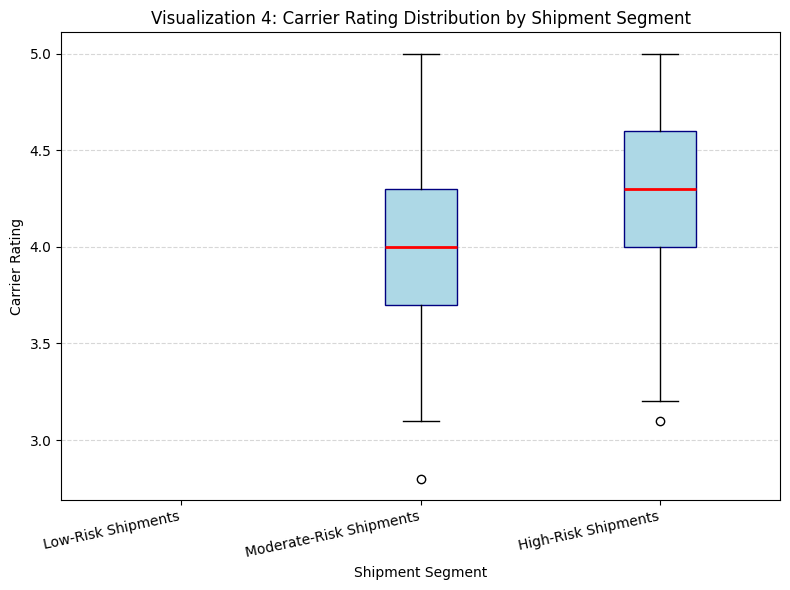

In [67]:
#Visualization 2: Box Plot
import matplotlib.pyplot as plt

segments_order = ["Low-Risk Shipments", "Moderate-Risk Shipments", "High-Risk Shipments"]
data_to_plot = [
    df_clustered[df_clustered["Segment_Name"] == seg]["Carrier_Rating"].values
    for seg in segments_order
]

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(data_to_plot, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='navy'),
                medianprops=dict(color='red', linewidth=2))

ax.set_xticklabels(segments_order, rotation=12, ha='right')
ax.set_xlabel("Shipment Segment")
ax.set_ylabel("Carrier Rating")
ax.set_title("Visualization 4: Carrier Rating Distribution by Shipment Segment")
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [68]:
print('''
The box plot shows the spread and median of Carrier Rating across segments.
Low-Risk Shipments have consistently higher and tightly grouped carrier
ratings, indicating reliable carriers. High-Risk Shipments show lower
medians and wider spread, suggesting carrier quality is a key driver of
delivery delays. SwiftShip should review carrier contracts for High-Risk routes.
''')


The box plot shows the spread and median of Carrier Rating across segments.
Low-Risk Shipments have consistently higher and tightly grouped carrier
ratings, indicating reliable carriers. High-Risk Shipments show lower
medians and wider spread, suggesting carrier quality is a key driver of
delivery delays. SwiftShip should review carrier contracts for High-Risk routes.

